In [ ]:
import numpy as np
import sys
from tqdm import tqdm

sys.path.insert(0, '../helpers/')
from helpers import LazyShotDataset
from fitting import fit_from_datasets

run_name = '/home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/data/R20_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000'
n_runs   = int(run_name.split('data/R')[1].split('_')[0])

results = []
for run_idx in tqdm(range(n_runs)):
    Z0   = LazyShotDataset(f'{run_name}/run_{run_idx:03d}/Z0/data_PROB.h5')
    Z100 = LazyShotDataset(f'{run_name}/run_{run_idx:03d}/Z100/data_PROB.h5')
    results.append(fit_from_datasets(Z0, Z100, f=0.3))

amps = np.array([r.amp for r in results])

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
phase = np.array([r.phase for r in results])

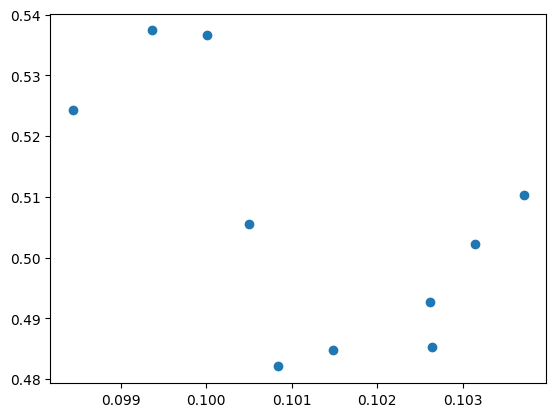

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(amps, phase)

0.10127651206400098
0.0017408776059664834


(array([1., 1., 1., 1., 1., 1., 0., 2., 1., 1.]),
 array([0.09844233, 0.09896993, 0.09949753, 0.10002514, 0.10055274,
        0.10108035, 0.10160795, 0.10213556, 0.10266316, 0.10319077,
        0.10371837]),
 <BarContainer object of 10 artists>)

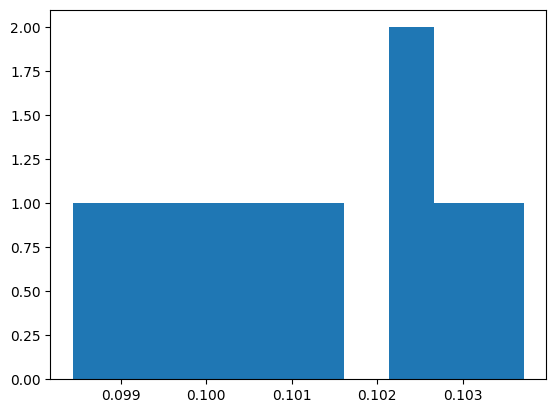

In [ ]:
print(np.mean(amps))
print(np.std(amps, ddof=1))
import matplotlib.pyplot as plt
plt.hist(amps)

In [ ]:
import pandas as pd

A1s = np.array([r.A1 for r in results])
A2s = np.array([r.A2 for r in results])
C1s = np.array([r.C1 for r in results])
C2s = np.array([r.C2 for r in results])
phi0s = np.array([r.phi0 for r in results])
Ass = np.array([r.As for r in results])
Acs = np.array([r.Ac for r in results])
amps = np.array([r.amp for r in results])
phases = np.array([r.phase for r in results])
logLs = np.array([r.logL for r in results])
nthetas = np.array([r.ntheta for r in results])
fs = np.array([r.f for r in results])
convergeds = np.array([r.converged for r in results])

df = pd.DataFrame({
    'A1': A1s,
    'A2': A2s,
    'C1': C1s,
    'C2': C2s,
    'phi0': phi0s,
    'As': Ass,
    'Ac': Acs,
    'amp': amps,
    'phase': phases,
    'logL': logLs,
    'ntheta': nthetas,
    'f': fs,
    'converged': convergeds,
})

df

,A1,A2,C1,C2,phi0,As,Ac,amp,phase,logL,ntheta,f,converged
0,0.506897,0.505987,0.925622,0.936764,1.885693,0.087927,0.048679,0.100503,0.505625,-2.300669e+07,2048,0.3,True
1,0.506984,0.506092,0.924418,0.937937,1.886001,0.090504,0.050660,0.103718,0.510301,-2.218311e+07,2048,0.3,True
2,0.507677,0.505761,0.925435,0.938292,1.888457,0.090411,0.049651,0.103148,0.502200,-2.354226e+07,2048,0.3,True
3,0.507277,0.505928,0.926329,0.937677,1.886116,0.085216,0.049287,0.098442,0.524371,-2.224773e+07,2048,0.3,True
4,0.507223,0.506019,0.926659,0.937711,1.888047,0.090790,0.047878,0.102640,0.485284,-2.313113e+07,2048,0.3,True
5,0.507104,0.506184,0.924534,0.938198,1.887057,0.089349,0.046755,0.100843,0.482099,-2.275083e+07,2048,0.3,True
6,0.506874,0.506326,0.926391,0.938558,1.887920,0.089789,0.047288,0.101480,0.484744,-2.339697e+07,2048,0.3,True
7,0.506619,0.505864,0.926778,0.938240,1.886250,0.090417,0.048541,0.102623,0.492694,-2.283029e+07,2048,0.3,True
8,0.506055,0.506007,0.927089,0.938069,1.889473,0.085945,0.051135,0.100006,0.536714,-2.256931e+07,2048,0.3,True
9,0.507294,0.506007,0.925665,0.937273,1.886463,0.085355,0.050864,0.099362,0.537410,-2.193006e+07,2048,0.3,True


In [ ]:
run_name.split('data/')[1]

'R10_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000'

In [ ]:
import pickle as pkl

with open('../results/' + run_name.split('data/')[1] + '.pkl', 'wb') as f:
    pkl.dump(df, f)